# Teste avaliativo para vaga de bolsista em engenharia/análise de dados

## 1. Extração dos dados

In [44]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import re
import requests
import sqlite3
import time

In [ ]:
# CONFIGURAR PASTA PARA SALVAR OS DADOS DA REQUISIÇÃO
os.makedirs('data', exist_ok=True)


URL = 'https://api.obrasgov.gestao.gov.br/obrasgov/api'
ENDPOINT = 'projeto-investimento'
MAX_ATTEMPT = 2
PAGE_SIZE = 10
UF = 'DF'
page = 0 


# PROJETOS DO DF
projetos_DF = []

# BUSCAR DADOS UTILIZANDO A API FORNECIDA
while True:
    response = requests.get(f'{URL}/{ENDPOINT}?uf={UF}&pagina={page}&tamanhoDaPagina={PAGE_SIZE}')

    # se vir um erro 404 indica que aquela página não existe ou a requisição está falhando
    if response.status_code == 404:
        print(f'Página {page} não existe. Finalizando.')
        break

    # se vir um erro 429, siginifica que meu ip tá sendo negado, preciso aguardar o rate-limit imposto pela api
    elif response.status_code == 429:
        retry_after = int(response.headers.get('x-rate-limit-retry-after-seconds', 2))
        print(f'Muitas requisições! Aguardando {retry_after} segundos...')
        time.sleep(retry_after)
        continue

    try:
        data = response.json()
    except ValueError as e:
        print(f'Erro ao decodificar JSON na página {page}: {e}')
        break

    # se pagina estiver vazia:
    if not data.get("content") or data.get("empty", False):
        print(f'Acabaram os dados para o UF = {UF}. ({page=})')
        break

    for item in data.get('content', []):
        projetos_DF.append(item)

    page += 1
    time.sleep(2)
        

print(f'Dados carregados. Total de dados encontrados = {len(projetos_DF)}.')


# SALVAR DADOS EM JSON:
json_path = os.path.join('data', 'projetos_DF.json')
with open(json_path, "w", encoding="utf-8") as file:
    json.dump(projetos_DF, file, ensure_ascii=False, indent=2)
print(f'Arquivo JSON salvo: {json_path}')


# SALVAR DADOS EM CSV:
csv_path = os.path.join('data', 'projetos_DF.csv')
df = pd.DataFrame(projetos_DF)
df.to_csv(csv_path, index=False, encoding="utf-8")
print(f'Arquivo CSV salvo: {csv_path}')


# SALVAR DADOS EM PICKLE:
pkl_path = os.path.join('data', 'projetos_DF.pkl')
with open(pkl_path, "wb") as file:
    pickle.dump(projetos_DF, file)
print(f'Arquivo Pickle salvo: {pkl_path}')

Acabaram os dados para o UF = DF. (page=84)
Dados carregados. Total de dados encontrados = 834.
Arquivo JSON salvo: data/projetos_DF.json
Arquivo CSV salvo: data/projetos_DF.csv
Arquivo Pickle salvo: data/projetos_DF.pkl


## 2. Busca exploratória dos dados

### 2.1 Visão geral dos dados

In [45]:
# CARREGAR OS DADOS VINDOS DE ALGUM ARQUIVO SALVO ACIMA, PARA ESSE EXEMPLO, IREI USAR OS DADOS VINDOS DO CSV:
df = pd.read_csv('data/projetos_DF.csv')

# quantidade de linhas e colunas:
rows, cols = df.shape

print(f'Dimensões (Linhas x Colunas): {rows} x {cols}')
print(f'Quantidade de linhas: {rows}')
print(f'Quantidade de colunas: {cols}')
print(f'Total de dados: (linhas x colunas) = {rows * cols}\n')

Dimensões (Linhas x Colunas): 834 x 31
Quantidade de linhas: 834
Quantidade de colunas: 31
Total de dados: (linhas x colunas) = 25854



In [46]:
# quantidade de valores nulos
qtd_null = df.isnull().sum()

# porcentagem de valores nulos:
percent_null = qtd_null / len(df) * 100

print("DADOS NULOS POR COLUNAS DOS DADOS OBTIDOS:\n")

for col in df.columns:
    print(f'{col}: {qtd_null[col]} --- ({percent_null[col]:.2f}%)')

DADOS NULOS POR COLUNAS DOS DADOS OBTIDOS:

idUnico: 0 --- (0.00%)
nome: 0 --- (0.00%)
cep: 453 --- (54.32%)
endereco: 445 --- (53.36%)
descricao: 0 --- (0.00%)
funcaoSocial: 0 --- (0.00%)
metaGlobal: 0 --- (0.00%)
dataInicialPrevista: 2 --- (0.24%)
dataFinalPrevista: 2 --- (0.24%)
dataInicialEfetiva: 812 --- (97.36%)
dataFinalEfetiva: 828 --- (99.28%)
dataCadastro: 0 --- (0.00%)
especie: 7 --- (0.84%)
natureza: 0 --- (0.00%)
naturezaOutras: 763 --- (91.49%)
situacao: 0 --- (0.00%)
descPlanoNacionalPoliticaVinculado: 576 --- (69.06%)
uf: 0 --- (0.00%)
qdtEmpregosGerados: 673 --- (80.70%)
descPopulacaoBeneficiada: 674 --- (80.82%)
populacaoBeneficiada: 678 --- (81.29%)
observacoesPertinentes: 718 --- (86.09%)
isModeladaPorBim: 259 --- (31.06%)
dataSituacao: 0 --- (0.00%)
tomadores: 0 --- (0.00%)
executores: 0 --- (0.00%)
repassadores: 0 --- (0.00%)
eixos: 0 --- (0.00%)
tipos: 0 --- (0.00%)
subTipos: 0 --- (0.00%)
fontesDeRecurso: 0 --- (0.00%)


In [47]:
# informações do dataframe:

print('INFORMAÇÕES DO DATAFRAME:\n')
df.info()

INFORMAÇÕES DO DATAFRAME:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 834 entries, 0 to 833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   idUnico                             834 non-null    object
 1   nome                                834 non-null    object
 2   cep                                 381 non-null    object
 3   endereco                            389 non-null    object
 4   descricao                           834 non-null    object
 5   funcaoSocial                        834 non-null    object
 6   metaGlobal                          834 non-null    object
 7   dataInicialPrevista                 832 non-null    object
 8   dataFinalPrevista                   832 non-null    object
 9   dataInicialEfetiva                  22 non-null     object
 10  dataFinalEfetiva                    6 non-null      object
 11  dataCadastro                   

### 2.2 Informações descritivas dos dados

In [48]:
# ESTATÍSTICAS DESCRITIVAS DOS DADOS

print('=' * 80)
print('ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS')
print('=' * 80)

# Estatísticas para colunas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    print(df[numeric_cols].describe().T)
else:
    print("Nenhuma coluna numérica encontrada inicialmente.\n")

print('\n' + '=' * 80)
print('ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS CATEGÓRICAS/TEXTO')
print('=' * 80)

# Estatísticas para colunas categóricas/texto
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    print(f"\n--- Coluna: '{col}' ---")
    print(f"Valores únicos: {df[col].nunique()}")
    print(f"Valores nulos: {df[col].isnull().sum()}")
    print(f"Top 5 valores mais frequentes:")
    print(df[col].value_counts().head())
    print()

# Resumo geral
print('\n' + '=' * 80)
print('RESUMO GERAL DAS ESTATÍSTICAS')
print('=' * 80)
print(f"Total de colunas numéricas: {len(numeric_cols)}")
print(f"Total de colunas categóricas/texto: {len(categorical_cols)}")
print(f"Memória utilizada pelo DataFrame: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS
Nenhuma coluna numérica encontrada inicialmente.


ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS CATEGÓRICAS/TEXTO

--- Coluna: 'idUnico' ---
Valores únicos: 606
Valores nulos: 0
Top 5 valores mais frequentes:
idUnico
60895.53-14    4
50835.53-40    4
36515.53-06    4
50954.53-97    4
2169.53-92     4
Name: count, dtype: int64


--- Coluna: 'nome' ---
Valores únicos: 570
Valores nulos: 0
Top 5 valores mais frequentes:
nome
CONSTRUÇÃO DE UNIDADE BÁSICA DE SAÚDE                                                                         9
Implantação de passarelas em estrutura mista nas rodovias do Sistema Rodoviária do Distrito Federal - SRDF    6
CONSTRUÇÃO DE UNIDADE DE ATENÇÃO ESPECIALIZADA EM SAÚDE                                                       6
202111-22-Ronald 1                                                                                            6
Obra de Desenvolvimento de Teste da Websis - Fabrica de Software - MDRR                

### 2.3 Qualidade dos dados

In [49]:
# QUALIDADE DOS DADOS

print('=' * 80)
print('ANÁLISE DE QUALIDADE DOS DADOS')
print('=' * 80)

# 1. Linhas duplicadas
rows_duplicated = df.duplicated().sum()
print(f'\n1. DUPLICATAS:')
print(f'   Quantidade de linhas duplicadas: {rows_duplicated}')
if rows_duplicated > 0:
    print(f'   Percentual de duplicatas: {(rows_duplicated/len(df)*100):.2f}%')

# 2. Valores nulos
total_null = df.isnull().sum().sum()
total_values = df.shape[0] * df.shape[1]
print(f'\n2. VALORES NULOS:')
print(f'   Total de valores nulos: {total_null}')
print(f'   Total de valores: {total_values}')
print(f'   Percentual de nulos: {(total_null/total_values*100):.2f}%')

# Top 10 colunas com mais nulos
print(f'\n   Top 10 colunas com mais valores nulos:')
null_counts = df.isnull().sum().sort_values(ascending=False).head(10)
for col, count in null_counts.items():
    pct = (count/len(df)*100)
    print(f'   {col}: {count} ({pct:.2f}%)')

# 3. Consistência de tipos
print(f'\n3. TIPOS DE DADOS:')
print(f'   Distribuição por tipo:')
print(df.dtypes.value_counts())

# 4. Valores únicos em colunas categóricas potenciais
print(f'\n4. CARDINALIDADE (colunas categóricas):')
categorical_potential = ['uf', 'situacao', 'especie', 'natureza']
for col in categorical_potential:
    if col in df.columns:
        print(f'   {col}: {df[col].nunique()} valores únicos')

# 5. Exemplo de linhas com valores nulos
print(f'\n5. EXEMPLO DE LINHAS COM VALORES NULOS:')
rows_with_nulls = df[df.isnull().any(axis=1)]
print(f'   Total de linhas com pelo menos um valor nulo: {len(rows_with_nulls)}')

# Mostrar apenas as primeiras 3 linhas e colunas com nulos
display(rows_with_nulls.head(3))

ANÁLISE DE QUALIDADE DOS DADOS

1. DUPLICATAS:
   Quantidade de linhas duplicadas: 188
   Percentual de duplicatas: 22.54%

2. VALORES NULOS:
   Total de valores nulos: 6890
   Total de valores: 25854
   Percentual de nulos: 26.65%

   Top 10 colunas com mais valores nulos:
   dataFinalEfetiva: 828 (99.28%)
   dataInicialEfetiva: 812 (97.36%)
   naturezaOutras: 763 (91.49%)
   observacoesPertinentes: 718 (86.09%)
   populacaoBeneficiada: 678 (81.29%)
   descPopulacaoBeneficiada: 674 (80.82%)
   qdtEmpregosGerados: 673 (80.70%)
   descPlanoNacionalPoliticaVinculado: 576 (69.06%)
   cep: 453 (54.32%)
   endereco: 445 (53.36%)

3. TIPOS DE DADOS:
   Distribuição por tipo:
object    31
Name: count, dtype: int64

4. CARDINALIDADE (colunas categóricas):
   uf: 1 valores únicos
   situacao: 7 valores únicos
   especie: 6 valores únicos
   natureza: 5 valores únicos

5. EXEMPLO DE LINHAS COM VALORES NULOS:
   Total de linhas com pelo menos um valor nulo: 834


,idUnico,nome,cep,endereco,descricao,funcaoSocial,metaGlobal,dataInicialPrevista,dataFinalPrevista,dataInicialEfetiva,...,observacoesPertinentes,isModeladaPorBim,dataSituacao,tomadores,executores,repassadores,eixos,tipos,subTipos,fontesDeRecurso
0,50379.53-54,DL - 304/2024 - Contratação de instituição par...,NaN,NaN,Contratação de instituição para execução de se...,Ampliação da capacidade de trafego visando a m...,Projetos Básicos e Executivos de Engenharia,2024-12-20,2027-12-05,NaN,...,NaN,False,2024-12-20,[],[{'nome': 'DEPARTAMENTO NACIONAL DE INFRAESTRU...,[],"[{'id': 3, 'descricao': 'Econômico'}]","[{'id': 25, 'descricao': 'Rodovia', 'idEixo': 3}]","[{'id': 4, 'descricao': 'Acessos Terrestres', ...","[{'origem': 'Federal', 'valorInvestimentoPrevi..."
1,42724.53-27,Escola Classe Crixá São Sebastião,NaN,NaN,"Construção de Escola em Tempo Integral, Escola...",A construção da nova escola beneficiará 977 es...,"Construção de Escola em Tempo Integral, Escola...",2024-09-02,2028-09-02,NaN,...,NaN,False,2025-09-05,[],[{'nome': 'SECRETARIA DE ESTADO DE EDUCACAO DO...,[{'nome': 'FUNDO NACIONAL DE DESENVOLVIMENTO D...,"[{'id': 4, 'descricao': 'Social'}]","[{'id': 46, 'descricao': 'Educação', 'idEixo':...","[{'id': 84, 'descricao': 'Educação', 'idTipo':...","[{'origem': 'Federal', 'valorInvestimentoPrevi..."
2,19970.53-78,Reajuste do Contrato 45/2021 - Contrução do Ce...,70.602-600,"SAIS Área Especial 3, Setor Policial Sul",Reajuste do Contrato 45/2021 - Construção do C...,Contribuir para a melhor formação dos bombeiro...,Construção de um novo centro de formação e de ...,2021-09-14,2024-08-28,NaN,...,NaN,False,2023-02-06,[],[{'nome': 'CORPO DE BOMBEIROS MILITAR DO DISTR...,[{'nome': 'CORPO DE BOMBEIROS MILITAR DO DISTR...,"[{'id': 1, 'descricao': 'Administrativo'}]","[{'id': 1, 'descricao': 'Segurança Pública', '...","[{'id': 59, 'descricao': 'Obras em Imóveis de ...","[{'origem': 'Federal', 'valorInvestimentoPrevi..."


### 2.4 Problemas e Inconsistências Identificados

Com base na análise exploratória, foram identificados os seguintes problemas:

**Problemas de Completude:**
- Alta taxa de valores nulos em várias colunas importantes
- Campos de data podem estar incompletos ou mal formatados

**Problemas de Consistência:**
- Valores numéricos podem estar armazenados como texto
- Datas em formatos inconsistentes
- CEPs com formatos variados (com/sem máscara)
- Listas armazenadas como strings

**Problemas de Qualidade:**
- Presença de duplicatas
- Valores categóricos que podem precisar de normalização
- Campos booleanos que podem estar como texto

**Ações de Tratamento:**
Todas essas inconsistências serão tratadas na próxima seção.

## 3. Tratamento dos dados

In [53]:
# TRATAMENTO DOS DADOS

new_df = df.copy()

# datas
DATE_COLS = [
    'dataInicialPrevista', 'dataFinalPrevista',
    'dataInicialEfetiva', 'dataFinalEfetiva',
    'dataCadastro', 'dataSituacao'
]

for date_col in DATE_COLS:
    if date_col in new_df.columns:
        new_df[date_col] = pd.to_datetime(new_df[date_col], errors='coerce')


# valores numericos
NUM_COLS = ['qdtEmpregosGerados', 'populacaoBeneficiada']

for num_col in NUM_COLS:
    if num_col in new_df.columns:
        new_df[num_col] = (
            new_df[num_col]
            .astype(str)
            .str.replace(r'[^0-9,.-]', '', regex=True)
            .str.replace(',', '.', regex=False)
        )
        new_df[num_col] = pd.to_numeric(new_df[num_col], errors='coerce')
        new_df[num_col] = new_df[num_col].fillna(0)

# textos
TEXT_COLS = [
    'cep', 'descricao', 'endereco', 'nome', 'funcaoSocial', 
    'metaGlobal', 'descPopulacaoBeneficiada',
    'observacoesPertinentes', 'descPlanoNacionalPoliticaVinculado'
]
for col in TEXT_COLS:
    if col in new_df.columns:
        new_df[col] = new_df[col].fillna('Não informado')
        
# tratando cep:
def tratar_cep(cep):
    if not cep or cep in ["nan", "NaN", "None"]:
        return ""
    digits = re.sub(r"\D", "", str(cep))
    return digits if len(digits) >= 8 else ""

new_df["cep"] = new_df["cep"].apply(tratar_cep)

        
# booleanos
BOOL_COLS = ['isModeladaPorBim']
for col in BOOL_COLS:
    if col in new_df.columns:
        new_df[col] = new_df[col].fillna(False)
        

# categorias
CATEGORY_COLS = ['uf', 'situacao', 'especie', 'natureza']
for col in CATEGORY_COLS:
    if col in new_df.columns:
        new_df[col] = new_df[col].astype('category')
        

# listas
LIST_COLS = ['tomadores', 'executores', 'repassadores', 'eixos', 'tipos', 'subTipos', 'fontesDeRecurso']

for col in LIST_COLS:
    if col in new_df.columns:
        new_df[col] = new_df[col].apply(lambda x: 'Não informado ou não existe' if x == '[]' else x)

        

new_df.info()
new_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 834 entries, 0 to 833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   idUnico                             834 non-null    object        
 1   nome                                834 non-null    object        
 2   cep                                 834 non-null    object        
 3   endereco                            834 non-null    object        
 4   descricao                           834 non-null    object        
 5   funcaoSocial                        834 non-null    object        
 6   metaGlobal                          834 non-null    object        
 7   dataInicialPrevista                 832 non-null    datetime64[ns]
 8   dataFinalPrevista                   832 non-null    datetime64[ns]
 9   dataInicialEfetiva                  22 non-null     datetime64[ns]
 10  dataFinalEfetiva          

,idUnico,nome,cep,endereco,descricao,funcaoSocial,metaGlobal,dataInicialPrevista,dataFinalPrevista,dataInicialEfetiva,...,observacoesPertinentes,isModeladaPorBim,dataSituacao,tomadores,executores,repassadores,eixos,tipos,subTipos,fontesDeRecurso
0,50379.53-54,DL - 304/2024 - Contratação de instituição par...,,Não informado,Contratação de instituição para execução de se...,Ampliação da capacidade de trafego visando a m...,Projetos Básicos e Executivos de Engenharia,2024-12-20,2027-12-05,NaT,...,Não informado,False,2024-12-20,Não informado ou não existe,[{'nome': 'DEPARTAMENTO NACIONAL DE INFRAESTRU...,Não informado ou não existe,"[{'id': 3, 'descricao': 'Econômico'}]","[{'id': 25, 'descricao': 'Rodovia', 'idEixo': 3}]","[{'id': 4, 'descricao': 'Acessos Terrestres', ...","[{'origem': 'Federal', 'valorInvestimentoPrevi..."
1,42724.53-27,Escola Classe Crixá São Sebastião,,Não informado,"Construção de Escola em Tempo Integral, Escola...",A construção da nova escola beneficiará 977 es...,"Construção de Escola em Tempo Integral, Escola...",2024-09-02,2028-09-02,NaT,...,Não informado,False,2025-09-05,Não informado ou não existe,[{'nome': 'SECRETARIA DE ESTADO DE EDUCACAO DO...,[{'nome': 'FUNDO NACIONAL DE DESENVOLVIMENTO D...,"[{'id': 4, 'descricao': 'Social'}]","[{'id': 46, 'descricao': 'Educação', 'idEixo':...","[{'id': 84, 'descricao': 'Educação', 'idTipo':...","[{'origem': 'Federal', 'valorInvestimentoPrevi..."
2,19970.53-78,Reajuste do Contrato 45/2021 - Contrução do Ce...,70602600,"SAIS Área Especial 3, Setor Policial Sul",Reajuste do Contrato 45/2021 - Construção do C...,Contribuir para a melhor formação dos bombeiro...,Construção de um novo centro de formação e de ...,2021-09-14,2024-08-28,NaT,...,Não informado,False,2023-02-06,Não informado ou não existe,[{'nome': 'CORPO DE BOMBEIROS MILITAR DO DISTR...,[{'nome': 'CORPO DE BOMBEIROS MILITAR DO DISTR...,"[{'id': 1, 'descricao': 'Administrativo'}]","[{'id': 1, 'descricao': 'Segurança Pública', '...","[{'id': 59, 'descricao': 'Obras em Imóveis de ...","[{'origem': 'Federal', 'valorInvestimentoPrevi..."
3,24797.53-15,Implantação de Passarelas nas Estradas Parque ...,,Não informado,Implantação de passarelas de estrutura mista n...,"Pedestres, no geral, demanda das ocupações lin...",Implantação de passarelas de estrutura mista n...,2023-08-30,2028-08-30,NaT,...,Não informado,False,2023-08-28,Não informado ou não existe,[{'nome': 'DEPARTAMENTO DE ESTRADAS DE RODAGEM...,"[{'nome': 'MINISTÉRIO DAS CIDADES', 'codigo': ...","[{'id': 3, 'descricao': 'Econômico'}]","[{'id': 24, 'descricao': 'Infraestrutura Urban...","[{'id': 57, 'descricao': 'Obra de Arte Especia...","[{'origem': 'Federal', 'valorInvestimentoPrevi..."
4,24822.53-70,"obra de construção da Cabine de Medição, loca...",,Não informado,"obra de construção da Cabine de Medição, loca...",A demanda de carga elétrica do Campus Darcy Ri...,A demanda de carga elétrica do Campus Darcy Ri...,2023-09-14,2024-03-14,NaT,...,Não informado,False,2023-08-29,Não informado ou não existe,"[{'nome': 'FUNDACAO UNIVERSIDADE DE BRASILIA',...","[{'nome': 'FUNDACAO UNIVERSIDADE DE BRASILIA',...","[{'id': 3, 'descricao': 'Econômico'}, {'id': 3...","[{'id': 31, 'descricao': 'Energia', 'idEixo': ...","[{'id': 95, 'descricao': 'Subestação', 'idTipo...","[{'origem': 'Federal', 'valorInvestimentoPrevi..."


### 3.1 Registro de problemas encontrados durante o tratamento

**Inconsistências identificadas durante o tratamento:**

In [54]:
# REGISTRO DE PROBLEMAS/ANOMALIAS ENCONTRADOS

problemas_encontrados = []

print("=" * 80)
print("VERIFICANDO INCONSISTÊNCIAS E ANOMALIAS")
print("=" * 80)


# 1. Verificar valores numéricos negativos onde não deveriam existir
print("\n2. ANOMALIAS EM VALORES NUMÉRICOS:")
numeric_cols = ['qdtEmpregosGerados', 'populacaoBeneficiada']
for col in numeric_cols:
    if col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            negative = df[df[col] < 0]
            if len(negative) > 0:
                msg = f"   - {col}: {len(negative)} valores negativos"
                print(msg)
                problemas_encontrados.append(msg)
        except:
            pass

# 2. Verificar CEPs inválidos (devem ter 8 dígitos)
print("\n3. ANOMALIAS EM CEPs:")
if 'cep' in df.columns:
    ceps_invalidos = df[df['cep'].str.len() != 8]
    if len(ceps_invalidos) > 0:
        msg = f"   - CEPs com formato inválido: {len(ceps_invalidos)}"
        print(msg)
        problemas_encontrados.append(msg)

print(f"\n{'=' * 80}")
print(f"TOTAL DE PROBLEMAS IDENTIFICADOS: {len(problemas_encontrados)}")
print(f"{'=' * 80}\n")

VERIFICANDO INCONSISTÊNCIAS E ANOMALIAS

2. ANOMALIAS EM VALORES NUMÉRICOS:

3. ANOMALIAS EM CEPs:
   - CEPs com formato inválido: 834

TOTAL DE PROBLEMAS IDENTIFICADOS: 1



In [43]:
# NORMALIZAR OS DADOS

# renomear colunas:

new_df = new_df.rename(
    columns=lambda x: x.replace('desc', 'descricao') if x.startswith('desc') else x
)

new_df = new_df.rename(
    columns=lambda x: x.replace('qdt', 'quantidade') if x.startswith('qdt') else x
)

new_df = new_df.rename(
    columns=lambda x: x.replace('is', 'eh') if x.startswith('is') else x
)

new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 606 entries, 0 to 833
Data columns (total 31 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   idUnico                                       606 non-null    object  
 1   nome                                          606 non-null    object  
 2   cep                                           606 non-null    object  
 3   endereco                                      606 non-null    object  
 4   descricaoricaoricao                           606 non-null    object  
 5   funcaoSocial                                  606 non-null    object  
 6   metaGlobal                                    606 non-null    object  
 7   dataInicialPrevista                           606 non-null    object  
 8   dataFinalPrevista                             606 non-null    object  
 9   dataInicialEfetiva                            606 non-null 

In [55]:
# remover duplicatas pelo id, nomr e cep
new_df = new_df.drop_duplicates(subset=['idUnico', 'nome', 'cep'])

new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 606 entries, 0 to 833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   idUnico                             606 non-null    object        
 1   nome                                606 non-null    object        
 2   cep                                 606 non-null    object        
 3   endereco                            606 non-null    object        
 4   descricao                           606 non-null    object        
 5   funcaoSocial                        606 non-null    object        
 6   metaGlobal                          606 non-null    object        
 7   dataInicialPrevista                 604 non-null    datetime64[ns]
 8   dataFinalPrevista                   604 non-null    datetime64[ns]
 9   dataInicialEfetiva                  13 non-null     datetime64[ns]
 10  dataFinalEfetiva               

In [56]:
# visualizando dados descritivos numericos e de datas:
new_df.describe()

,dataInicialPrevista,dataFinalPrevista,dataInicialEfetiva,dataFinalEfetiva,dataCadastro,qdtEmpregosGerados,populacaoBeneficiada,dataSituacao
count,604,604,13,4,606,606.000000,6.060000e+02,606
mean,2021-07-30 18:04:46.092715008,2023-06-30 02:15:53.642384128,2022-06-16 16:36:55.384615424,2023-02-15 00:00:00,2023-08-28 17:06:32.079207936,3.867987,1.207205e+04,2023-08-27 20:49:54.059405824
min,2003-06-26 00:00:00,2007-11-09 00:00:00,2018-05-17 00:00:00,2022-03-22 00:00:00,2021-01-20 00:00:00,0.000000,0.000000e+00,2007-11-09 00:00:00
25%,2020-11-21 06:00:00,2022-01-31 12:00:00,2019-10-25 00:00:00,2022-03-28 00:00:00,2021-12-22 12:00:00,0.000000,0.000000e+00,2022-03-30 00:00:00
50%,2022-05-10 00:00:00,2024-03-12 00:00:00,2023-12-11 00:00:00,2022-09-05 00:00:00,2023-11-22 12:00:00,0.000000,0.000000e+00,2023-12-28 12:00:00
75%,2024-04-11 12:00:00,2025-12-25 12:00:00,2024-03-30 00:00:00,2023-07-26 00:00:00,2025-05-05 00:00:00,0.000000,0.000000e+00,2025-05-05 00:00:00
max,2025-12-31 00:00:00,2032-12-31 00:00:00,2024-08-01 00:00:00,2024-12-02 00:00:00,2025-09-29 00:00:00,250.000000,2.817381e+06,2025-09-29 00:00:00
std,NaN,NaN,NaN,NaN,NaN,22.930345,1.635122e+05,NaN


In [57]:
# dados descritivos com textos
new_df.describe(include='object')

,idUnico,nome,cep,endereco,descricao,funcaoSocial,metaGlobal,naturezaOutras,descPlanoNacionalPoliticaVinculado,descPopulacaoBeneficiada,observacoesPertinentes,tomadores,executores,repassadores,eixos,tipos,subTipos,fontesDeRecurso
count,606,606,606,606,606,606,606,61,606,606,606,606,606,606,606,606,606,606
unique,606,570,82,221,558,447,430,30,58,33,4,48,73,51,15,48,78,461
top,50379.53-54,CONSTRUÇÃO DE UNIDADE BÁSICA DE SAÚDE,,Não informado,Projeto de desenvolvimento do MDR para integra...,Segurança Pública,Escola de Educação Infantil Tipo B,outros,Não informado,Não informado,Não informado,Não informado ou não existe,[{'nome': 'FUNDO NACIONAL DE DESENVOLVIMENTO D...,Não informado ou não existe,"[{'id': 1, 'descricao': 'Administrativo'}]","[{'id': 5, 'descricao': 'Administrativo', 'idE...","[{'id': 59, 'descricao': 'Obras em Imóveis de ...","[{'origem': 'Federal', 'valorInvestimentoPrevi..."
freq,1,7,398,328,7,27,33,15,417,501,530,340,75,271,242,100,75,87


## 4. Armazenamento dos dados

In [58]:
# SALVAR OS DADOS NUM BANCO DE DADOS:

# irei utilizar o sqlite3, pois é um banco de dados relacional leve
# que já vem embutido no python, ideal para protótipos e projetos
# pequenos, além de não precisar de um servidor

PATH_DB = 'data/projetosDF.db'

print("=" * 80)
print("ARMAZENAMENTO DOS DADOS EM BANCO DE DADOS RELACIONAL")
print("=" * 80)
print(f"\nBanco de dados: SQLite")
print(f"Caminho: {PATH_DB}")
print(f"Tabela: projetos\n")

# Iniciando conexão com o banco de dados
conn = sqlite3.connect(PATH_DB)
cursor = conn.cursor()

# Criação da tabela (corrigindo erro de digitação: descricaoricao -> descricao)
cursor.execute("""
CREATE TABLE IF NOT EXISTS projetos (
    idUnico TEXT PRIMARY KEY,
    nome TEXT,
    cep TEXT,
    endereco TEXT,
    descricao TEXT,
    funcaoSocial TEXT,
    metaGlobal TEXT,
    dataInicialPrevista DATE,
    dataFinalPrevista DATE,
    dataInicialEfetiva DATE,
    dataFinalEfetiva DATE,
    dataCadastro DATE,
    especie TEXT,
    natureza TEXT,
    naturezaOutras TEXT,
    situacao TEXT,
    descricaoPlanoNacionalPoliticaVinculado TEXT,
    uf TEXT,
    quantidadeEmpregosGerados REAL,
    descricaoPopulacaoBeneficiada TEXT,
    populacaoBeneficiada REAL,
    observacoesPertinentes TEXT,
    ehModeladaPorBim INTEGER,
    dataSituacao DATE,
    tomadores TEXT,
    executores TEXT,
    repassadores TEXT,
    eixos TEXT,
    tipos TEXT,
    subTipos TEXT,
    fontesDeRecurso TEXT
)
""")

conn.commit()
print("Tabela 'projetos' criada com sucesso!")

ARMAZENAMENTO DOS DADOS EM BANCO DE DADOS RELACIONAL

Banco de dados: SQLite
Caminho: data/projetosDF.db
Tabela: projetos

Tabela 'projetos' criada com sucesso!


In [59]:
# MANTER CONSISTENCIA DOS DADOS AO INSERIR NO BANCO:

# Converter NaT em None e datas em texto ISO
for col in new_df.select_dtypes(include=['datetime64[ns]']).columns:
    new_df[col] = new_df[col].apply(lambda x: x.strftime('%Y-%m-%d') if pd.notnull(x) else None)

# Booleanos como inteiros
new_df['ehModeladaPorBim'] = new_df['ehModeladaPorBim'].astype(int)


# Outras colunas: substituir valores nulos por string vazia
new_df = new_df.replace({np.nan: "", "Não informado": "", "nan": ""})


for _, row in new_df.iterrows():
    cursor.execute("""
        INSERT OR REPLACE INTO projetos VALUES (
            ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?
        )
    """, tuple(row))

conn.commit()
conn.close()

KeyError: 'ehModeladaPorBim'

In [60]:
# VERIFICAR SE OS DADOS FORAM INSERIDOS CORRETAMENTE

print("=" * 80)
print("VERIFICAÇÃO DOS DADOS NO BANCO")
print("=" * 80)

conn = sqlite3.connect(PATH_DB)
cursor = conn.cursor()

# Contar registros
cursor.execute('SELECT COUNT(*) FROM projetos')
total = cursor.fetchone()[0]
print(f"\nTotal de registros inseridos: {total}")

# Mostrar primeiras 5 linhas
print(f"\nPrimeiras 5 linhas (idUnico, nome, situacao):")
print("-" * 80)
cursor.execute('SELECT idUnico, nome, situacao FROM projetos LIMIT 5')
for row in cursor.fetchall():
    print(f"ID: {row[0][:30]}... | Nome: {row[1][:30]}... | Situação: {row[2]}")

# Verificar distribuição por situação
print(f"\n\nDistribuição por situação:")
print("-" * 80)
cursor.execute('SELECT situacao, COUNT(*) as total FROM projetos GROUP BY situacao ORDER BY total DESC')
for row in cursor.fetchall():
    print(f"{row[0]}: {row[1]} projetos")

conn.close()
print(f"\n{'=' * 80}")
print("Dados armazenados com sucesso no banco de dados!")
print(f"{'=' * 80}\n")

VERIFICAÇÃO DOS DADOS NO BANCO

Total de registros inseridos: 606

Primeiras 5 linhas (idUnico, nome, situacao):
--------------------------------------------------------------------------------
ID: 50379.53-54... | Nome: DL - 304/2024 - Contratação de... | Situação: Cadastrada
ID: 42724.53-27... | Nome: Escola Classe Crixá São Sebast... | Situação: Cancelada
ID: 19970.53-78... | Nome: Reajuste do Contrato 45/2021 -... | Situação: Cadastrada
ID: 24797.53-15... | Nome: Implantação de Passarelas nas ... | Situação: Cadastrada
ID: 24822.53-70... | Nome: obra de construção da  Cabine ... | Situação: Cadastrada


Distribuição por situação:
--------------------------------------------------------------------------------
Cadastrada: 452 projetos
Em execução: 75 projetos
Concluída: 56 projetos
Inativada: 13 projetos
Paralisada: 6 projetos
Cancelada: 3 projetos
Inacabada: 1 projetos

Dados armazenados com sucesso no banco de dados!



## 5. Análise Qualitativa

In [61]:
# CARREGAR OS DADOS DO BANCO DE DADOS PARA ANÁLISE

print("=" * 80)
print("ANÁLISE QUALITATIVA E QUANTITATIVA")
print("=" * 80)

conn = sqlite3.connect(PATH_DB)
df = pd.read_sql_query("SELECT * FROM projetos", conn)
conn.close()

print(f"\nDados carregados: {len(df)} registros")
print(f"Colunas: {len(df.columns)}\n")

# Converter datas para análise
date_cols = ['dataInicialPrevista', 'dataFinalPrevista', 'dataInicialEfetiva', 
             'dataFinalEfetiva', 'dataCadastro', 'dataSituacao']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

ANÁLISE QUALITATIVA E QUANTITATIVA

Dados carregados: 606 registros
Colunas: 31



### 5.1 Distribuição das Situações dos Projetos

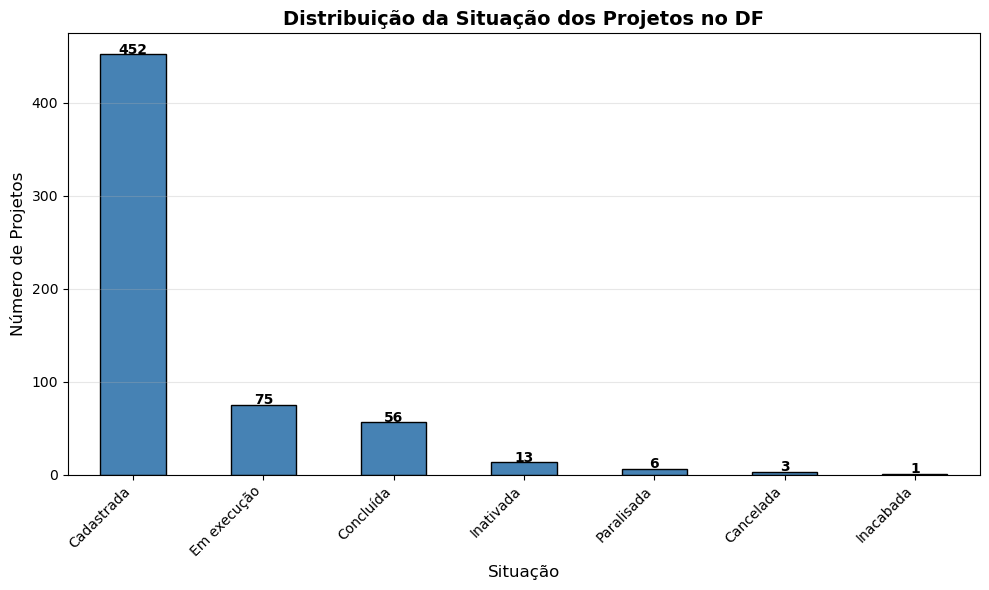


ESTATÍSTICAS DE SITUAÇÃO:
------------------------------------------------------------
Cadastrada: 452 projetos (74.6%)
Em execução: 75 projetos (12.4%)
Concluída: 56 projetos (9.2%)
Inativada: 13 projetos (2.1%)
Paralisada: 6 projetos (1.0%)
Cancelada: 3 projetos (0.5%)
Inacabada: 1 projetos (0.2%)


In [62]:
# Gráfico de barras - Situação dos Projetos
fig, ax = plt.subplots(figsize=(10, 6))
situacao_counts = df['situacao'].value_counts()
situacao_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribuição da Situação dos Projetos no DF', fontsize=14, fontweight='bold')
ax.set_xlabel('Situação', fontsize=12)
ax.set_ylabel('Número de Projetos', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Adicionar valores nas barras
for i, v in enumerate(situacao_counts):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.show()

# Estatísticas
print("\nESTATÍSTICAS DE SITUAÇÃO:")
print("-" * 60)
for situacao, count in situacao_counts.items():
    pct = (count / len(df)) * 100
    print(f"{situacao}: {count} projetos ({pct:.1f}%)")

**Insights:**
- A grande maioria dos projetos está registrada como Cadastrada, Em execução ou Concluída, com apenas uma pequena fração inacabada ou cancelada.
- Isso indica que o programa apresenta alta taxa de continuidade e execução, com a maior parte das iniciativas avançando conforme o planejado.

### 5.2 Análise Temporal dos Projetos

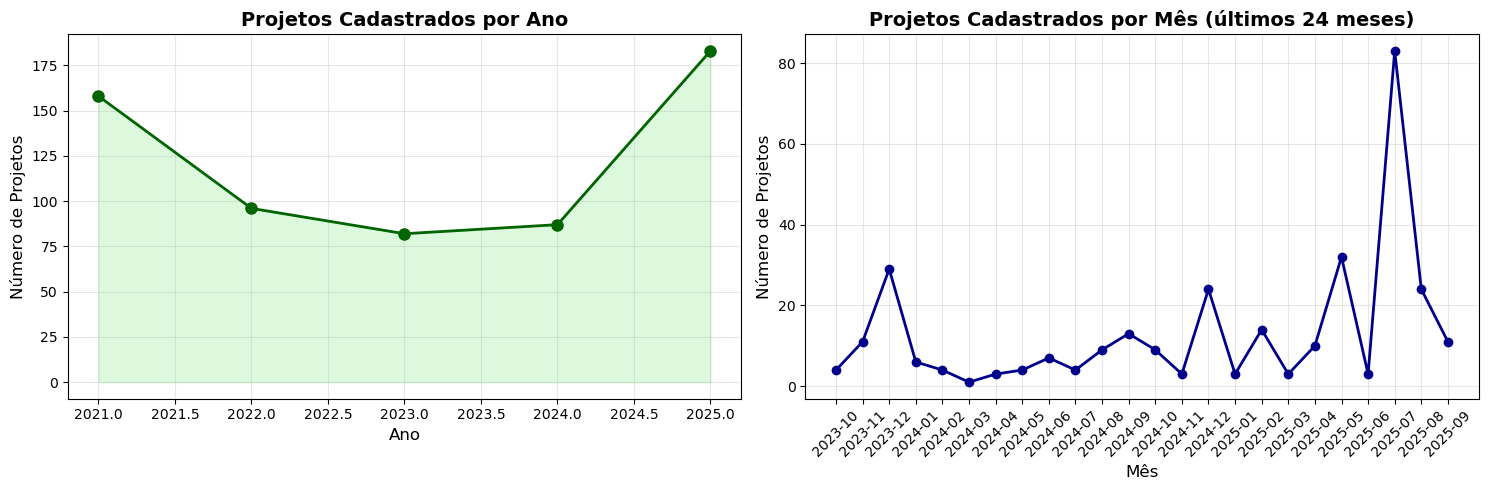


Total de projetos com data de cadastro: 606
Período: 2021-01-20 00:00:00 até 2025-09-29 00:00:00


In [63]:
# Análise temporal - Cadastro de projetos ao longo do tempo
df_com_data = df[df['dataCadastro'].notna()].copy()
df_com_data['anoCadastro'] = df_com_data['dataCadastro'].dt.year
df_com_data['mesCadastro'] = df_com_data['dataCadastro'].dt.to_period('M')

# Gráfico de linha - Projetos cadastrados por ano
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Por ano
cadastros_ano = df_com_data['anoCadastro'].value_counts().sort_index()
axes[0].plot(cadastros_ano.index, cadastros_ano.values, marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[0].set_title('Projetos Cadastrados por Ano', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ano', fontsize=12)
axes[0].set_ylabel('Número de Projetos', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(cadastros_ano.index, cadastros_ano.values, alpha=0.3, color='lightgreen')

# Por mês (últimos 24 meses)
cadastros_mes = df_com_data['mesCadastro'].value_counts().sort_index().tail(24)
axes[1].plot(cadastros_mes.index.astype(str), cadastros_mes.values, marker='o', linewidth=2, markersize=6, color='darkblue')
axes[1].set_title('Projetos Cadastrados por Mês (últimos 24 meses)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mês', fontsize=12)
axes[1].set_ylabel('Número de Projetos', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nTotal de projetos com data de cadastro: {len(df_com_data)}")
print(f"Período: {df_com_data['dataCadastro'].min()} até {df_com_data['dataCadastro'].max()}")

**Insights:**
- Observa-se uma tendência crescente no número de projetos cadastrados ao longo dos anos, com picos significativos em 2021 e 2025, indicando períodos de maior atividade de registro (anos que antecedem as eleições).
- Observa-se um pico expressivo em julho de 2025, indicando possível influência de políticas públicas, ciclos de planejamento ou liberação orçamentária nesse período.
- A análise mensal evidencia sazonalidade no processo de cadastro, permitindo identificar períodos de maior atividade nos meses finais dos anos.

### 5.3 Análise de Espécie e Natureza dos Projetos

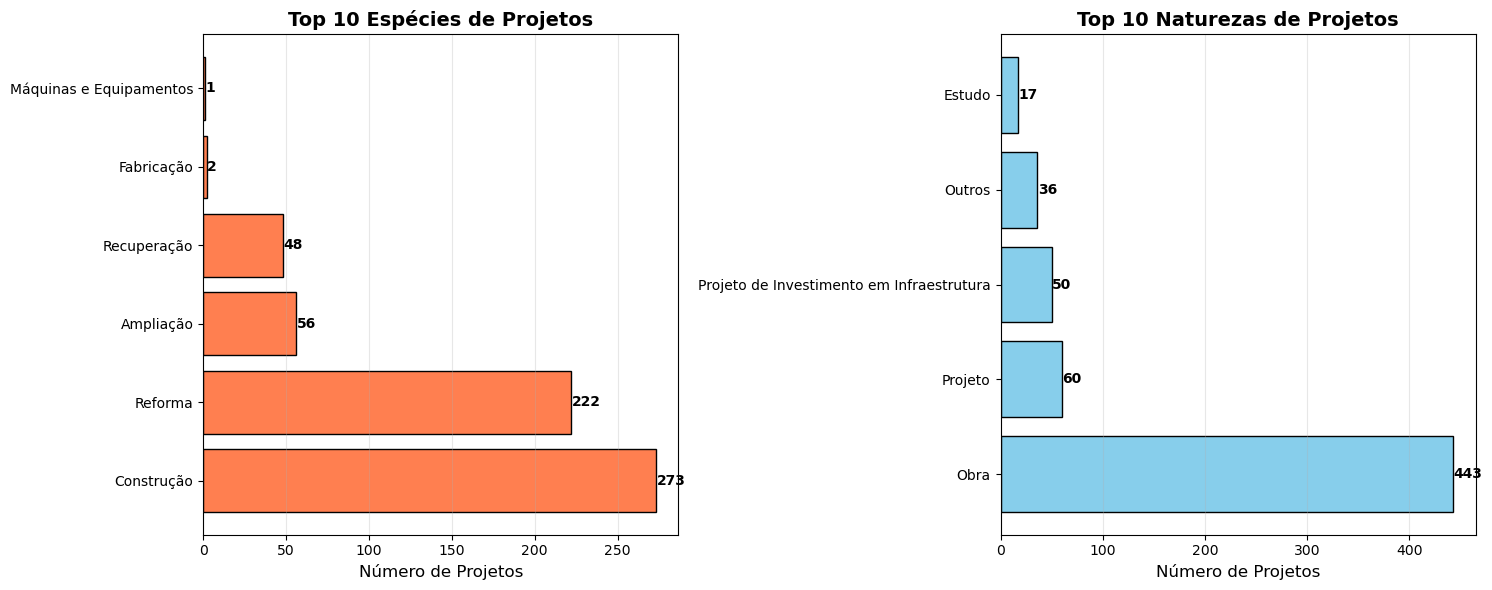


DISTRIBUIÇÃO POR ESPÉCIE:
------------------------------------------------------------
Construção: 273 projetos
Reforma: 222 projetos
Ampliação: 56 projetos
Recuperação: 48 projetos
Fabricação: 2 projetos


DISTRIBUIÇÃO POR NATUREZA:
------------------------------------------------------------
Obra: 443 projetos
Projeto: 60 projetos
Projeto de Investimento em Infraestrutura: 50 projetos
Outros: 36 projetos
Estudo: 17 projetos


In [64]:
# Análise de Espécie e Natureza
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Espécie
if 'especie' in df.columns and df['especie'].notna().sum() > 0:
    especie_counts = df['especie'].value_counts().head(10)
    axes[0].barh(especie_counts.index, especie_counts.values, color='coral', edgecolor='black')
    axes[0].set_title('Top 10 Espécies de Projetos', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Número de Projetos', fontsize=12)
    axes[0].grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(especie_counts.values):
        axes[0].text(v + 0.5, i, str(v), va='center', fontweight='bold')

# Natureza
if 'natureza' in df.columns and df['natureza'].notna().sum() > 0:
    natureza_counts = df['natureza'].value_counts().head(10)
    axes[1].barh(natureza_counts.index, natureza_counts.values, color='skyblue', edgecolor='black')
    axes[1].set_title('Top 10 Naturezas de Projetos', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Número de Projetos', fontsize=12)
    axes[1].grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(natureza_counts.values):
        axes[1].text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDISTRIBUIÇÃO POR ESPÉCIE:")
print("-" * 60)
if 'especie' in df.columns:
    for esp, count in df['especie'].value_counts().head(5).items():
        print(f"{esp}: {count} projetos")

print("\n\nDISTRIBUIÇÃO POR NATUREZA:")
print("-" * 60)
if 'natureza' in df.columns:
    for nat, count in df['natureza'].value_counts().head(5).items():
        print(f"{nat}: {count} projetos")

**Insights:**
- A maioria dos projetos se concentra em Construção e Reforma, mostrando um foco claro em obras físicas e estruturais.
- Projetos de Ampliação e Recuperação aparecem com menor frequência, enquanto Fabricação e Máquinas e Equipamentos são quase residuais.
- A natureza Obra domina amplamente o gráfico, reforçando que os projetos têm foco físico e de execução.

### 5.4 Análise de Impacto Social (Empregos e População Beneficiada)

ANÁLISE DE IMPACTO SOCIAL: EMPREGOS GERADOS E POPULAÇÃO BENEFICIADA

PROJETOS COM DADOS COMPLETOS: 24 de 606 projetos totais (4.0%)

TOP 5 PROJETOS COM MAIORES EMPREGOS GERADOS:
--------------------------------------------------------------------------------

1. Reforma do Pronto Socorro (PS) - HOSPITAL REGIONAL DE CEILÂNDIA - HRC
   Empregos Gerados: 250
   População Beneficiada: 9.500
   Situação: Cadastrada

2. Retauração da DF-001- Tr. Pistão Sul, Recanto das Emas
   Empregos Gerados: 240
   População Beneficiada: 496.000
   Situação: Concluída

3. Implantação Interseção DF-463 com rodovia DF-001
   Empregos Gerados: 200
   População Beneficiada: 70.000
   Situação: Cadastrada

4. Viaduto da BR-020
   Empregos Gerados: 200
   População Beneficiada: 245.000
   Situação: Concluída

5. Construção de Unidade de Atenção Especializada em Saúde - Hospital Regional de São Sebastião 
   Empregos Gerados: 150
   População Beneficiada: 313.565
   Situação: Cadastrada


TOP 5 PROJETOS COM MAIO

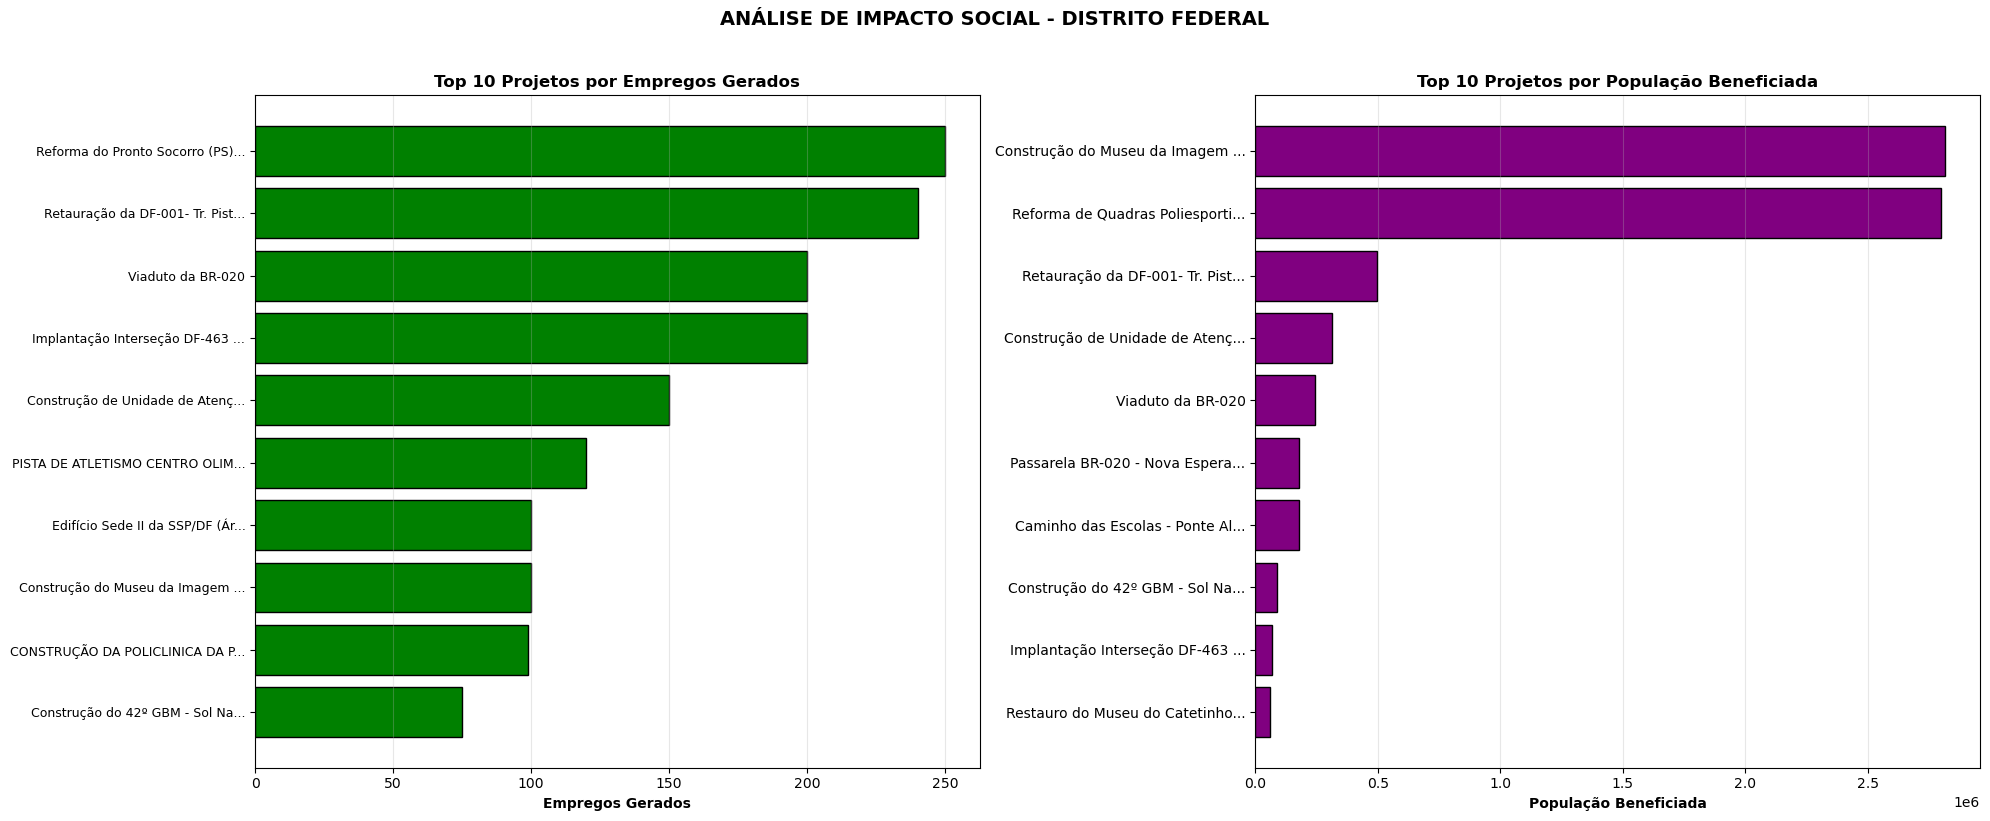

In [67]:
# ANÁLISE DETALHADA: RELAÇÃO EMPREGOS vs POPULAÇÃO

print("=" * 80)
print("ANÁLISE DE IMPACTO SOCIAL: EMPREGOS GERADOS E POPULAÇÃO BENEFICIADA")
print("=" * 80)

# Filtrar apenas projetos com dados completos
df_completo = df[
    (df['quantidadeEmpregosGerados'].notnull()) & 
    (df['populacaoBeneficiada'].notnull()) &
    (df['quantidadeEmpregosGerados'] > 0) &
    (df['populacaoBeneficiada'] > 0)
].copy()

print(f"\nPROJETOS COM DADOS COMPLETOS: {len(df_completo)} de {len(df)} projetos totais ({len(df_completo)/len(df)*100:.1f}%)")
print("=" * 80)


# 1. TOP PROJETOS POR EMPREGOS GERADOS
print("\nTOP 5 PROJETOS COM MAIORES EMPREGOS GERADOS:")
print("-" * 80)

top_empregos = df_completo.nlargest(5, 'quantidadeEmpregosGerados')[
    ['nome', 'quantidadeEmpregosGerados', 'populacaoBeneficiada', 'situacao']
]

for i, (idx, row) in enumerate(top_empregos.iterrows(), 1):
    print(f"\n{i}. {row['nome']}")
    print(f"   Empregos Gerados: {row['quantidadeEmpregosGerados']:,.0f}".replace(',', '.'))
    print(f"   População Beneficiada: {row['populacaoBeneficiada']:,.0f}".replace(',', '.'))
    print(f"   Situação: {row['situacao']}")


# 2. TOP PROJETOS POR POPULAÇÃO BENEFICIADA
print("\n\n" + "=" * 80)
print("TOP 5 PROJETOS COM MAIOR POPULAÇÃO BENEFICIADA:")
print("-" * 80)

top_populacao = df_completo.nlargest(5, 'populacaoBeneficiada')[
    ['nome', 'populacaoBeneficiada', 'quantidadeEmpregosGerados', 'situacao']
]

for i, (idx, row) in enumerate(top_populacao.iterrows(), 1):
    print(f"\n{i}. {row['nome']}")
    print(f"   População Beneficiada: {row['populacaoBeneficiada']:,.0f}".replace(',', '.'))
    print(f"   Empregos Gerados: {row['quantidadeEmpregosGerados']:,.0f}".replace(',', '.'))
    print(f"   Situação: {row['situacao']}")

# GRAFICOS:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))  # 1 linha, 2 colunas

# 1. Top 10 por empregos (barras horizontais)
ax1 = axes[0]
top10_emp = df_completo.nlargest(10, 'quantidadeEmpregosGerados').sort_values('quantidadeEmpregosGerados')
y_pos = range(len(top10_emp))
ax1.barh(y_pos, top10_emp['quantidadeEmpregosGerados'], color='green', edgecolor='black')
ax1.set_yticks(y_pos)
ax1.set_yticklabels([nome[:30] + '...' if len(nome) > 30 else nome for nome in top10_emp['nome']], fontsize=9)
ax1.set_xlabel('Empregos Gerados', fontsize=10, fontweight='bold')
ax1.set_title('Top 10 Projetos por Empregos Gerados', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Top 10 por população (barras horizontais)
ax2 = axes[1]
top10_pop = df_completo.nlargest(10, 'populacaoBeneficiada').sort_values('populacaoBeneficiada')
y_pos = range(len(top10_pop))
ax2.barh(y_pos, top10_pop['populacaoBeneficiada'], color='purple', edgecolor='black')
ax2.set_yticks(y_pos)
ax2.set_yticklabels([nome[:30] + '...' if len(nome) > 30 else nome for nome in top10_pop['nome']], fontsize=10)
ax2.set_xlabel('População Beneficiada', fontsize=10, fontweight='bold')
ax2.set_title('Top 10 Projetos por População Beneficiada', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('ANÁLISE DE IMPACTO SOCIAL - DISTRITO FEDERAL', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Insights:**
- Há uma correlação esperada entre empregos gerados e população beneficiada, mas com variações
- Projetos em diferentes situações apresentam diferentes perfis de impacto social
- Muitos projetos não possuem informações sobre impacto social, indicando possível problema de preenchimento ou negligência.

### 5.5 Análise de Prazo e Execução

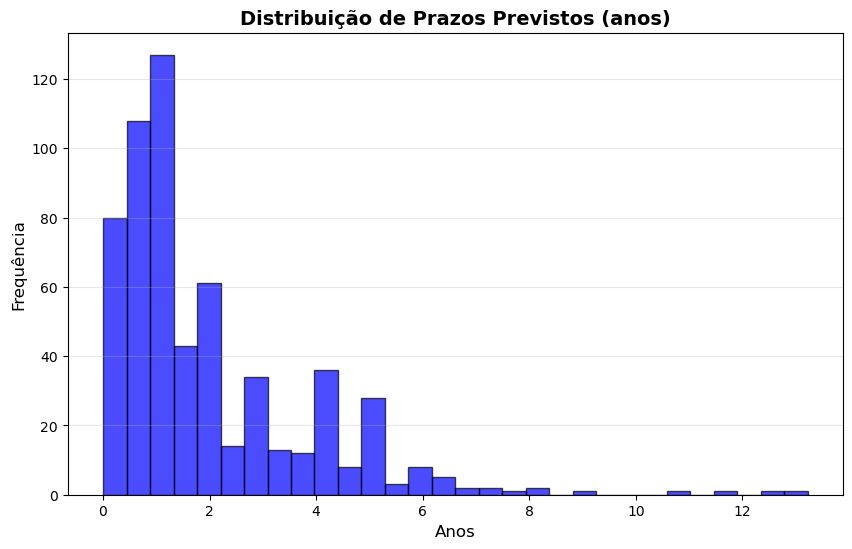

In [66]:
# Filtrar apenas registros com datas válidas e prazo positivo
df_prazos = df[
    df['dataInicialPrevista'].notna() & df['dataFinalPrevista'].notna()
].copy()

df_prazos['prazo_previsto_dias'] = (df_prazos['dataFinalPrevista'] - df_prazos['dataInicialPrevista']).dt.days
prazos_previsto = df_prazos[df_prazos['prazo_previsto_dias'] > 0]['prazo_previsto_dias']

# Plotar histograma
plt.figure(figsize=(10,6))
plt.hist(prazos_previsto / 365, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title('Distribuição de Prazos Previstos (anos)', fontsize=14, fontweight='bold')
plt.xlabel('Anos', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

**Insights sobre Prazos:**
- Há variação significativa nos prazos previstos dos projetos, sendo que a maioria tem prazo médio de 1-2 anos.

---

## 6. Conclusões Finais

Este estudo analisou os projetos de investimento no Distrito Federal. Foram identificados diversos aspectos importantes:

**1. Volume e Situação dos Projetos:**
- A maioria dos projetos está na fase de cadastro, indicando um pipeline robusto de iniciativas planejadas
- Uma parcela significativa já está em execução ou foi concluída, demonstrando capacidade de implementação

**2. Gestão de Prazos:**
- Existe variação nos prazos de execução dos projetos
- Alguns projetos apresentam atrasos em relação ao planejado, o que é comum em obras públicas
- A análise temporal permite identificar padrões e tendências ao longo do tempo

**3. Qualidade dos Dados:**
- Foram identificadas inconsistências nos dados, especialmente:
  - Valores nulos em campos importantes
  - Datas incompletas ou inconsistentes
  - Falta de padronização em alguns campos
- Essas questões foram tratadas e documentadas no processo

### Principais Padrões Identificados

1. **Concentração de Tipos**: Alguns tipos de projetos são mais frequentes que outros
2. **Sazonalidade**: O cadastro de projetos pode apresentar padrões temporais
3. **Correlação Social**: Projetos maiores tendem a gerar mais empregos e beneficiar mais pessoas

### Hipóteses sobre as Causas

**Para os atrasos:**
- Complexidade técnica de alguns projetos
- Questões burocráticas e de aprovação
- Disponibilidade de recursos financeiros

**Para a incompletude dos dados:**
- Falta de padronização no processo de cadastro
- Campos opcionais não sendo preenchidos
- Diferentes responsáveis com diferentes níveis de rigor no preenchimento

### Recomendações

1. **Melhoria na Coleta de Dados:**
   - Tornar obrigatório o preenchimento de campos críticos (impacto social, datas)
   - Implementar validações automáticas no momento do cadastro
   
2. **Monitoramento de Prazos:**
   - Criar alertas para projetos com risco de atraso
   - Analisar causas raiz dos atrasos sistemáticos
   
3. **Transparência:**
   - Manter dados atualizados e acessíveis
   - Publicar relatórios periódicos sobre o andamento dos projetos

4. **Análises Futuras:**
   - Correlacionar com dados orçamentários
   - Analisar eficiência por tipo de projeto
   - Estudar impacto econômico de longo prazo

---

**Preparado por:** Lucas Borges (222015159)  
**Repositório:** github.com/lcsgborges/teste-engenharia-dados-LabLivre